# Attention and Transformers with PyTorch

This lab is aligned with the lecture on **attention mechanisms**, **self-attention**, **multi-head attention**, **transformers**, **positional embeddings**, and the **BERT family**.

## (60–90 min)



## 0. Imports

In [1]:
import math
import re
from collections import Counter

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## 1. Part 1 — Dataset, tokenization, vocabulary, encoding

In [2]:
# If needed:
# %pip install -q datasets

from datasets import load_dataset

dataset = load_dataset("ag_news")

# Training pool (later split into train + validation)
full_train_data = list(dataset["train"])[:6000]

# Independent test set (never used in training or validation)
independent_test_data = list(dataset["test"])[:2000]

texts = [x["text"] for x in full_train_data]
labels = [x["label"] for x in full_train_data]

test_texts = [x["text"] for x in independent_test_data]
test_labels = [x["label"] for x in independent_test_data]

print(texts[0])
print("Classes:", sorted(set(labels)))


Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Classes: [0, 1, 2, 3]


In [3]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()

counter = Counter()
for text in texts:
    counter.update(tokenize(text))

vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in counter.most_common(10000):
    vocab[word] = len(vocab)

print("Vocab size:", len(vocab))


Vocab size: 10002


In [4]:
max_len = 32

def encode(text):
    tokens = tokenize(text)
    ids = [vocab.get(tok, vocab["<unk>"]) for tok in tokens]
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids += [vocab["<pad>"]] * (max_len - len(ids))
    return ids

X_all = torch.tensor([encode(t) for t in texts], dtype=torch.long)
y_all = torch.tensor(labels, dtype=torch.long)

X_test = torch.tensor([encode(t) for t in test_texts], dtype=torch.long)
y_test = torch.tensor(test_labels, dtype=torch.long)

full_dataset = TensorDataset(X_all, y_all)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=128)

print("All data:", X_all.shape)
print("Independent test:", X_test.shape)
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))


All data: torch.Size([6000, 32])
Independent test: torch.Size([2000, 32])
Train size: 4800
Validation size: 1200


## 2. Scaled Dot-Product Attention (Optional)

In [5]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)

    torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))

    weights = torch.softmax(scores, dim=-1)
    output = torch.matmul(weights, V)

    return output, weights


## 3. Self-Attention Layer (Optional)

In [6]:
class SelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        out, weights = scaled_dot_product_attention(Q, K, V)
        return out, weights


## 4. Transformer Encoder Classifier

In [7]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_classes, max_len):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_len, embed_dim)

        self.attention = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(embed_dim)

        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim),
        )
        self.norm2 = nn.LayerNorm(embed_dim)

        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        batch_size, seq_len = x.shape
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)

        x = self.embedding(x) + self.pos_embedding(positions)

        attn_out, attn_weights = self.attention(x,x,x)
        x = self.norm1(x + attn_out)

        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)

        x = x.mean(dim=1)
        return self.classifier(x)


## 5. Training + validation metrics

In [8]:
model = TransformerClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    num_heads=4,
    ff_dim=256,
    num_classes=4,
    max_len=max_len,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [9]:
def evaluate_loss_accuracy(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


In [10]:
num_epochs = 5

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == yb).sum().item()
        running_total += yb.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    val_loss, val_acc = evaluate_loss_accuracy(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")


Epoch 1: train_loss=1.1725 | train_acc=0.4612 | val_loss=0.8780 | val_acc=0.6367
Epoch 2: train_loss=0.6904 | train_acc=0.7344 | val_loss=0.7272 | val_acc=0.7242
Epoch 3: train_loss=0.4446 | train_acc=0.8394 | val_loss=0.6325 | val_acc=0.7692
Epoch 4: train_loss=0.2736 | train_acc=0.9119 | val_loss=0.6583 | val_acc=0.7800
Epoch 5: train_loss=0.1448 | train_acc=0.9533 | val_loss=0.7617 | val_acc=0.7767


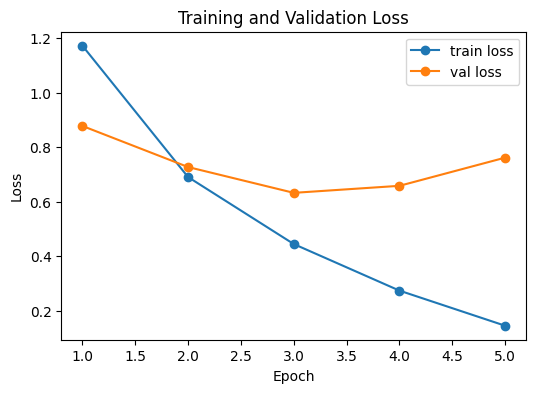

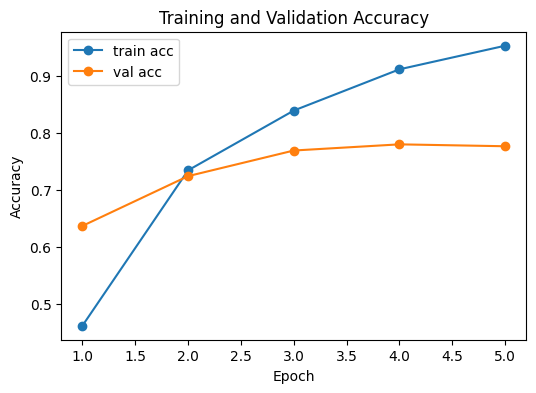

In [11]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, train_losses, marker="o", label="train loss")
plt.plot(epochs, val_losses, marker="o", label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, train_accuracies, marker="o", label="train acc")
plt.plot(epochs, val_accuracies, marker="o", label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


## 6. Independent test set

In [12]:
test_loss, test_acc = evaluate_loss_accuracy(model, test_loader, criterion)
print(f"Independent test loss: {test_loss:.4f}")
print(f"Independent test accuracy: {test_acc:.4f}")


Independent test loss: 0.9702
Independent test accuracy: 0.7200


## 7. Optional DistilBERT with train / validation / test

Use this only as an optional extension or short demo.

If you got a Hugging Face error with `additional_chat_templates`, upgrade the libraries and restart the kernel before running the next cells.


In [ ]:
# Run this only if needed, then RESTART the kernel:
# %pip install -q -U "transformers>=4.46,<5" "huggingface_hub>=0.24,<1" datasets accelerate


In [14]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

checkpoint = "distilbert/distilbert-base-uncased"

#completed
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
bert_model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=4,
).to(device)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
# Smaller subset so this still fits a class demo
bert_full_train_data = list(dataset["train"])[:2400]
bert_test_data = list(dataset["test"])[:800]

bert_texts = [x["text"] for x in bert_full_train_data]
bert_labels = [x["label"] for x in bert_full_train_data]

bert_test_texts = [x["text"] for x in bert_test_data]
bert_test_labels = [x["label"] for x in bert_test_data]

split_idx = int(0.8 * len(bert_texts))

bert_train_texts = bert_texts[:split_idx]
bert_train_labels = bert_labels[:split_idx]

bert_val_texts = bert_texts[split_idx:]
bert_val_labels = bert_labels[split_idx:]

print(len(bert_train_texts), len(bert_val_texts), len(bert_test_texts))


1920 480 800


In [16]:
def bert_tokenize(texts, tokenizer, max_length=128):
    return tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors="pt",
    )

#completed
train_enc = bert_tokenize(bert_train_texts, tokenizer)
val_enc = bert_tokenize(bert_val_texts, tokenizer)
test_enc = bert_tokenize(bert_test_texts, tokenizer)


In [17]:
bert_train_ds = TensorDataset(
    train_enc["input_ids"],
    train_enc["attention_mask"],
    torch.tensor(bert_train_labels, dtype=torch.long),
)

bert_val_ds = TensorDataset(
    val_enc["input_ids"],
    val_enc["attention_mask"],
    torch.tensor(bert_val_labels, dtype=torch.long),
)

bert_test_ds = TensorDataset(
    test_enc["input_ids"],
    test_enc["attention_mask"],
    torch.tensor(bert_test_labels, dtype=torch.long),
)

bert_train_loader = DataLoader(bert_train_ds, batch_size=16, shuffle=True)
bert_val_loader = DataLoader(bert_val_ds, batch_size=32)
bert_test_loader = DataLoader(bert_test_ds, batch_size=32)


In [18]:
bert_optimizer = optim.AdamW(bert_model.parameters(), lr=2e-5)
bert_criterion = nn.CrossEntropyLoss()

def evaluate_bert(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for input_ids, attention_mask, labels in loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)
            #completed
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
            )
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item() * input_ids.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)


    return total_loss / total, correct / total

In [20]:
bert_num_epochs = 2

bert_train_losses = []
bert_val_losses = []
bert_train_accuracies = []
bert_val_accuracies = []

for epoch in range(bert_num_epochs):
    bert_model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for input_ids, attention_mask, labels in bert_train_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)


        #completed
        outputs = bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )
        loss = outputs.loss
        logits = outputs.logits

        bert_optimizer.zero_grad()
        loss.backward()
        bert_optimizer.step()

        running_loss += loss.item() * input_ids.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    val_loss, val_acc = evaluate_bert(bert_model, bert_val_loader)

    bert_train_losses.append(train_loss)
    bert_val_losses.append(val_loss)
    bert_train_accuracies.append(train_acc)
    bert_val_accuracies.append(val_acc)


    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

Epoch 1: train_loss=0.1863 | train_acc=0.9495 | val_loss=0.2772 | val_acc=0.9187
Epoch 2: train_loss=0.1158 | train_acc=0.9682 | val_loss=0.3154 | val_acc=0.8979


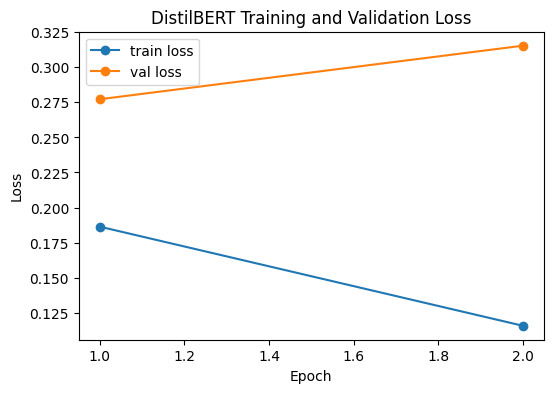

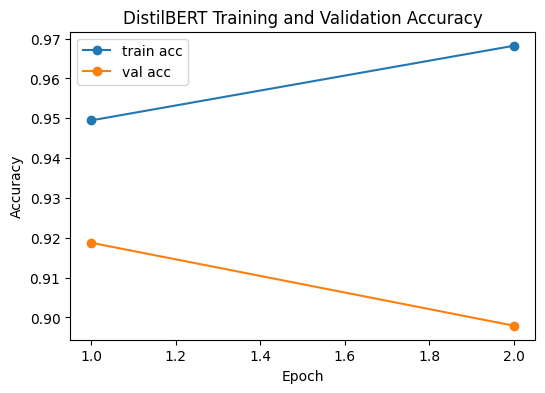

In [21]:
epochs = range(1, bert_num_epochs + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, bert_train_losses, marker="o", label="train loss")
plt.plot(epochs, bert_val_losses, marker="o", label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DistilBERT Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, bert_train_accuracies, marker="o", label="train acc")
plt.plot(epochs, bert_val_accuracies, marker="o", label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DistilBERT Training and Validation Accuracy")
plt.legend()
plt.show()


In [22]:
bert_test_loss, bert_test_acc = evaluate_bert(bert_model, bert_test_loader)
print(f"DistilBERT independent test loss: {bert_test_loss:.4f}")
print(f"DistilBERT independent test accuracy: {bert_test_acc:.4f}")


DistilBERT independent test loss: 0.3776
DistilBERT independent test accuracy: 0.8650
